# Adversarial Attacks on EuroSAT — PyTorch


## 1. Setup

In [1]:
!pip install kaggle pyngrok -q
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os, warnings, random
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Libraries ready!")
print(f"   PyTorch: {torch.__version__}")
print(f"   Device : {device}")

✅ Libraries ready!
   PyTorch: 2.11.0+cu128
   Device : cuda


## 2. Download & Load EuroSAT

In [2]:
from google.colab import files

# Upload your kaggle.json
files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download EuroSAT
!kaggle datasets download -d apollo2506/eurosat-dataset -q
!unzip -q eurosat-dataset.zip -d /content/eurosat

DATA_DIR = "/content/eurosat/EuroSAT"
IMG_SIZE = 64
print("✅ Download complete")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
✅ Download complete


In [3]:
# ImageFolder only ever treats directories as classes — this is the fix
# for the "14 classes instead of 10" bug from the TF notebook (there it came
# from os.listdir() picking up non-directory entries).
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()   # scales pixels to [0, 1], shape (C, H, W)
])

full_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
CLASS_NAMES  = full_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)

print(f"✅ EuroSAT loaded!")
print(f"   Classes ({NUM_CLASSES}): {CLASS_NAMES}")

✅ EuroSAT loaded!
   Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [4]:
# Train / test split
train_size = int(0.8 * len(full_dataset))
test_size  = len(full_dataset) - train_size
train_ds, test_ds = random_split(
    full_dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

print(f"✅ Dataset ready!")
print(f"   Train images: {len(train_ds)}")
print(f"   Test images : {len(test_ds)}")

✅ Dataset ready!
   Train images: 21600
   Test images : 5400


## 3. Model

In [5]:
class EuroSATCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)   # raw logits — use softmax where needed

model = EuroSATCNN(NUM_CLASSES).to(device)
print(model)

EuroSATCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


## 4. Train

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
EPOCHS = 10

history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == lbls).sum().item()
        total += lbls.size(0)
    train_loss = running_loss / total
    train_acc  = correct / total

    model.eval()
    val_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            loss = criterion(out, lbls)
            val_loss += loss.item() * imgs.size(0)
            v_correct += (out.argmax(1) == lbls).sum().item()
            v_total += lbls.size(0)
    val_loss /= v_total
    val_acc = v_correct / v_total

    history["train_acc"].append(train_acc); history["val_acc"].append(val_acc)
    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_acc={train_acc:.3f} val_acc={val_acc:.3f} "
          f"train_loss={train_loss:.3f} val_loss={val_loss:.3f}")

print(f"\n✅ Model trained! Final Test Accuracy: {val_acc*100:.2f}%")

Epoch 1/10 | train_acc=0.439 val_acc=0.605 train_loss=1.467 val_loss=1.076
Epoch 2/10 | train_acc=0.632 val_acc=0.637 train_loss=1.008 val_loss=0.969
Epoch 3/10 | train_acc=0.682 val_acc=0.712 train_loss=0.872 val_loss=0.764
Epoch 4/10 | train_acc=0.706 val_acc=0.758 train_loss=0.798 val_loss=0.654
Epoch 5/10 | train_acc=0.729 val_acc=0.756 train_loss=0.740 val_loss=0.657
Epoch 6/10 | train_acc=0.740 val_acc=0.762 train_loss=0.718 val_loss=0.633
Epoch 7/10 | train_acc=0.752 val_acc=0.768 train_loss=0.682 val_loss=0.629
Epoch 8/10 | train_acc=0.764 val_acc=0.691 train_loss=0.658 val_loss=0.866
Epoch 9/10 | train_acc=0.770 val_acc=0.790 train_loss=0.633 val_loss=0.564
Epoch 10/10 | train_acc=0.781 val_acc=0.796 train_loss=0.616 val_loss=0.576

✅ Model trained! Final Test Accuracy: 79.63%


In [7]:
torch.save(model.state_dict(), "eurosat_model.pt")
print("✅ Model saved!")

✅ Model saved!


In [8]:
# Load saved model — skip training next time you open this notebook
model = EuroSATCNN(NUM_CLASSES).to(device)
model.load_state_dict(torch.load("eurosat_model.pt", map_location=device))
model.eval()
print("✅ Model loaded — no retraining needed!")

✅ Model loaded — no retraining needed!


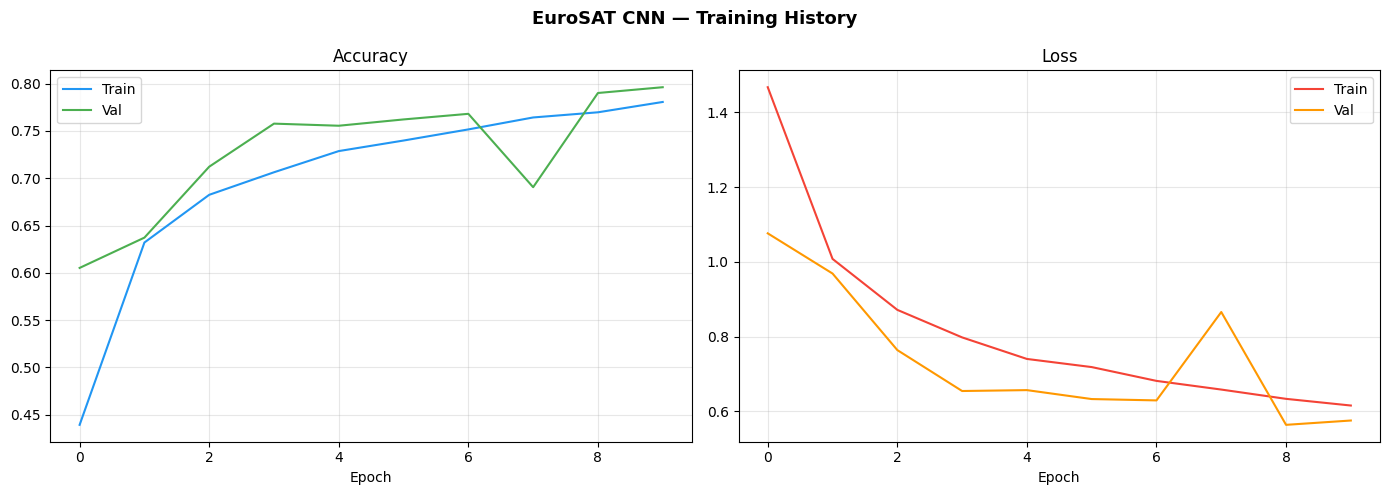

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EuroSAT CNN — Training History", fontsize=13, fontweight="bold")

axes[0].plot(history["train_acc"], label="Train", color="#2196F3")
axes[0].plot(history["val_acc"],   label="Val",   color="#4CAF50")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["train_loss"], label="Train", color="#F44336")
axes[1].plot(history["val_loss"],   label="Val",   color="#FF9800")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Test data + shared helpers


In [10]:
test_images, test_labels = [], []
for imgs, lbls in test_loader:
    test_images.append(imgs)
    test_labels.append(lbls)
    if sum(t.shape[0] for t in test_images) >= 200:
        break
test_images = torch.cat(test_images, dim=0)[:200].to(device)
test_labels = torch.cat(test_labels, dim=0)[:200].to(device)

# 5 images used by every per-image (non-batched) attack
bb_images = test_images[:5]
bb_labels = test_labels[:5]

print(f"✅ Test data ready — {len(test_images)} images loaded")

✅ Test data ready — 200 images loaded


In [11]:
def predict_label(model, image):
    """Model's own prediction for a single (C,H,W) image — never the ground truth."""
    model.eval()
    with torch.no_grad():
        return model(image.unsqueeze(0)).argmax(dim=1).item()

def batch_accuracy(model, images, labels):
    model.eval()
    with torch.no_grad():
        preds = model(images).argmax(dim=1)
    return (preds == labels).float().mean().item()

def show_attack_grid(orig, adv, orig_label, adv_label, title):
    diff = np.abs(adv - orig) * 10
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    axes[0].imshow(np.transpose(orig, (1, 2, 0))); axes[0].set_title(f"Original\n{orig_label}", color="green"); axes[0].axis("off")
    axes[1].imshow(np.clip(np.transpose(adv, (1, 2, 0)), 0, 1))
    color = "red" if orig_label != adv_label else "green"
    axes[1].set_title(f"Adversarial\n{adv_label}", color=color); axes[1].axis("off")
    axes[2].imshow(np.clip(np.transpose(diff, (1, 2, 0)), 0, 1)); axes[2].set_title("Perturbation (×10)"); axes[2].axis("off")
    plt.tight_layout(); plt.show()

## 6. FGSM (White-Box)

In [12]:
def fgsm_attack(model, images, labels, epsilon):
    images = images.clone().detach().to(device).requires_grad_(True)
    labels = labels.to(device)
    outputs = model(images)
    loss = F.cross_entropy(outputs, labels)
    model.zero_grad()
    loss.backward()
    grad_sign = images.grad.data.sign()
    adv = images + epsilon * grad_sign
    return torch.clamp(adv, 0, 1).detach()

epsilons = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3]
fgsm_accuracies = []

print("Running FGSM at different epsilon values...\n")
for eps in epsilons:
    adv_imgs = fgsm_attack(model, test_images, test_labels, eps)
    acc = batch_accuracy(model, adv_imgs, test_labels)
    fgsm_accuracies.append(acc * 100)
    print(f"  eps={eps:.2f} → Accuracy: {acc*100:.1f}%  Attack Success: {100-acc*100:.1f}%")

print("\n✅ FGSM complete!")

Running FGSM at different epsilon values...

  eps=0.00 → Accuracy: 76.0%  Attack Success: 24.0%
  eps=0.01 → Accuracy: 32.5%  Attack Success: 67.5%
  eps=0.05 → Accuracy: 10.0%  Attack Success: 90.0%
  eps=0.10 → Accuracy: 7.5%  Attack Success: 92.5%
  eps=0.20 → Accuracy: 10.0%  Attack Success: 90.0%
  eps=0.30 → Accuracy: 12.5%  Attack Success: 87.5%

✅ FGSM complete!


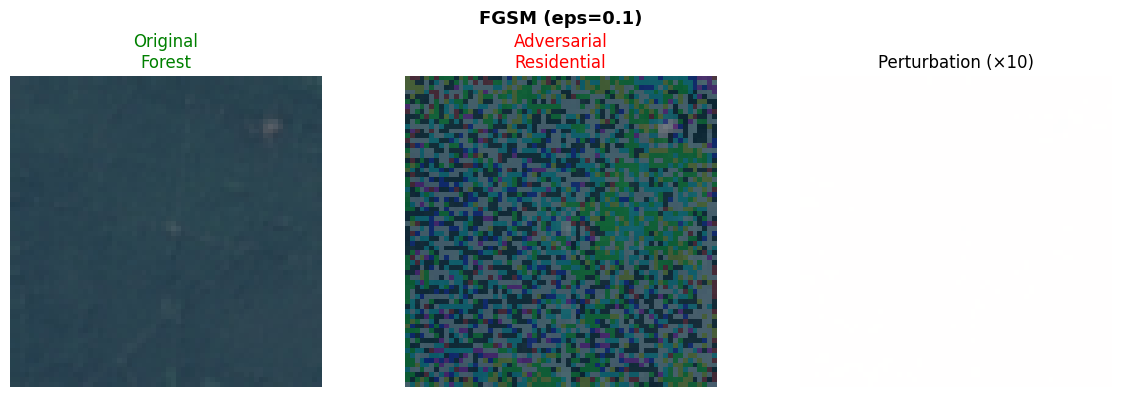

In [13]:
adv_sample = fgsm_attack(model, bb_images[:1], bb_labels[:1], 0.1)[0]
orig_pred_lbl = CLASS_NAMES[predict_label(model, bb_images[0])]
adv_pred_lbl  = CLASS_NAMES[predict_label(model, adv_sample)]
show_attack_grid(bb_images[0].cpu().numpy(), adv_sample.cpu().numpy(),
                  orig_pred_lbl, adv_pred_lbl, "FGSM (eps=0.1)")

## 7. PGD (White-Box)

In [14]:
def pgd_attack(model, images, labels, epsilon=0.1, alpha=0.01, num_steps=40):
    images = images.to(device)
    labels = labels.to(device)
    adv = images + torch.empty_like(images).uniform_(-epsilon, epsilon)
    adv = torch.clamp(adv, 0, 1).detach()
    for _ in range(num_steps):
        adv.requires_grad_(True)
        outputs = model(adv)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        adv = adv + alpha * adv.grad.sign()
        eta = torch.clamp(adv - images, -epsilon, epsilon)
        adv = torch.clamp(images + eta, 0, 1).detach()
    return adv

pgd_epsilons = [0.0, 0.05, 0.1]
pgd_accuracies = []
print("Running PGD...\n")
for eps in pgd_epsilons:
    if eps == 0.0:
        adv_imgs = test_images
    else:
        adv_imgs = pgd_attack(model, test_images, test_labels, epsilon=eps, alpha=eps/10, num_steps=40)
    acc = batch_accuracy(model, adv_imgs, test_labels)
    pgd_accuracies.append(acc * 100)
    print(f"  eps={eps:.2f} → Accuracy: {acc*100:.1f}%  Attack Success: {100-acc*100:.1f}%")

print("\n✅ PGD complete!")

Running PGD...

  eps=0.00 → Accuracy: 76.0%  Attack Success: 24.0%
  eps=0.05 → Accuracy: 0.0%  Attack Success: 100.0%
  eps=0.10 → Accuracy: 0.0%  Attack Success: 100.0%

✅ PGD complete!


## 8. UAP — Universal Adversarial Perturbation (White-Box)

In [15]:
def uap_attack(model, images, labels, epsilon=0.1, num_epochs=5, lr=0.01, batch_size=32):
    uap = torch.zeros_like(images[0:1], requires_grad=True)
    optimizer = torch.optim.Adam([uap], lr=lr)
    for epoch in range(num_epochs):
        for i in range(0, len(images), batch_size):
            batch = images[i:i+batch_size]
            lbls  = labels[i:i+batch_size]
            adv = torch.clamp(batch + uap, 0, 1)
            outputs = model(adv)
            loss = -F.cross_entropy(outputs, lbls)   # maximize loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            with torch.no_grad():
                uap.clamp_(-epsilon, epsilon)
    return uap.detach()

print("Learning universal perturbation...\n")
uap = uap_attack(model, test_images, test_labels, epsilon=0.1, num_epochs=5)
adv_imgs = torch.clamp(test_images + uap, 0, 1)
uap_acc = batch_accuracy(model, adv_imgs, test_labels) * 100

print(f"  Clean Accuracy : {batch_accuracy(model, test_images, test_labels)*100:.1f}%")
print(f"  UAP Accuracy   : {uap_acc:.1f}%")
print(f"  Attack Success : {100-uap_acc:.1f}%")
print("\n✅ UAP complete!")

Learning universal perturbation...

  Clean Accuracy : 76.0%
  UAP Accuracy   : 13.0%
  Attack Success : 87.0%

✅ UAP complete!


## 9. NewtonFool (White-Box)

In [16]:
def newtonfool_attack(model, image, num_steps=100, eta=0.01):
    orig_pred = predict_label(model, image)
    adv = image.clone().detach()
    for step in range(num_steps):
        adv.requires_grad_(True)
        outputs = model(adv.unsqueeze(0))
        probs = F.softmax(outputs, dim=1)[0]
        curr_label = torch.argmax(probs).item()
        if curr_label != orig_pred:
            print(f"    Fooled at step {step+1}!")
            break
        f_x = probs[orig_pred]
        grad = torch.autograd.grad(f_x, adv)[0]
        grad_norm = grad.norm().item() + 1e-8
        step_size = eta * f_x.item() / (grad_norm**2 + 1e-8)
        with torch.no_grad():
            adv = torch.clamp(adv - step_size * grad, 0, 1).detach()
    return adv, orig_pred

print("Running NewtonFool Attack on sample images...\n")
nf_results = []
for i in range(5):
    adv, orig_pred = newtonfool_attack(model, bb_images[i], num_steps=100, eta=0.01)
    adv_pred = predict_label(model, adv)
    is_adv = adv_pred != orig_pred
    l2 = (adv - bb_images[i]).norm().item()
    nf_results.append({"is_adv": is_adv, "l2": l2, "adv": adv})
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: {CLASS_NAMES[orig_pred]:20s} → {CLASS_NAMES[adv_pred]:20s} L2={l2:.4f} {status}")

nf_success = sum(1 for r in nf_results if r["is_adv"])
print(f"\n✅ NewtonFool complete! Success: {nf_success}/5")

Running NewtonFool Attack on sample images...

  Image 1: Forest               → Forest               L2=0.4265 ❌ Failed
    Fooled at step 72!
  Image 2: SeaLake              → River                L2=0.2037 ✅ Fooled
    Fooled at step 61!
  Image 3: AnnualCrop           → SeaLake              L2=0.3325 ✅ Fooled
    Fooled at step 55!
  Image 4: Pasture              → AnnualCrop           L2=0.1610 ✅ Fooled
    Fooled at step 68!
  Image 5: Industrial           → Residential          L2=1.2366 ✅ Fooled

✅ NewtonFool complete! Success: 4/5


## 10. DBB — Decision-Based Boundary Attack (Black-Box)


In [17]:
def boundary_attack(model, image, num_steps=100, step_size=0.05):
    orig_pred = predict_label(model, image)
    adv = torch.rand_like(image)
    for _ in range(1000):
        if predict_label(model, adv) != orig_pred:
            break
        adv = torch.rand_like(image)
    for step in range(num_steps):
        candidate = torch.clamp(adv + step_size * (image - adv), 0, 1)
        if predict_label(model, candidate) != orig_pred:
            adv = candidate
        else:
            step_size *= 0.9
    return adv, orig_pred

print("Running DBB (Decision-Based Boundary) Attack...\n")
dbb_results = []
for i in range(5):
    adv, orig_pred = boundary_attack(model, bb_images[i], num_steps=100)
    adv_pred = predict_label(model, adv)
    is_adv = adv_pred != orig_pred
    l2 = (adv - bb_images[i]).norm().item()
    dbb_results.append({"is_adv": is_adv, "l2": l2})
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: {CLASS_NAMES[orig_pred]:20s} → {CLASS_NAMES[adv_pred]:20s} L2={l2:.4f} {status}")

dbb_success = sum(1 for r in dbb_results if r["is_adv"])
print(f"\n✅ DBB complete! Success: {dbb_success}/5")

Running DBB (Decision-Based Boundary) Attack...

  Image 1: Forest               → Highway              L2=2.6234 ✅ Fooled
  Image 2: SeaLake              → River                L2=0.9418 ✅ Fooled
  Image 3: AnnualCrop           → Pasture              L2=2.2437 ✅ Fooled
  Image 4: Pasture              → Highway              L2=4.6175 ✅ Fooled
  Image 5: Industrial           → Residential          L2=7.7125 ✅ Fooled

✅ DBB complete! Success: 5/5


## 11. C&W — Carlini & Wagner (White-Box)

In [18]:
def cw_attack(model, images, labels, num_classes, max_iter=50, lr=0.01, c=1.0):
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    w = torch.zeros_like(images, requires_grad=True)
    optimizer = torch.optim.Adam([w], lr=lr)
    best_adv = images.clone()
    best_l2 = torch.full((images.size(0),), float("inf"), device=device)

    for _ in range(max_iter):
        adv = torch.clamp(images + w, 0, 1)
        outputs = model(adv)
        onehot = F.one_hot(labels, num_classes).float()
        real  = (onehot * outputs).sum(dim=1)
        other = ((1 - onehot) * outputs - onehot * 1e4).max(dim=1)[0]
        f_loss = torch.clamp(real - other, min=-0.01)
        l2 = (w ** 2).flatten(1).sum(dim=1)
        loss = (l2 + c * f_loss).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            adv_now = torch.clamp(images + w, 0, 1)
            preds_now = model(adv_now).argmax(dim=1)
            l2_now = (w ** 2).flatten(1).sum(dim=1)
            improved = (preds_now != labels) & (l2_now < best_l2)
            best_adv[improved] = adv_now[improved]
            best_l2[improved] = l2_now[improved]

    return best_adv

print("Running C&W Attack...\n")
cw_accuracies = []
cw_c_values = [0.0, 0.5, 1.0, 2.0]

for c_val in cw_c_values:
    if c_val == 0.0:
        adv_imgs = test_images[:50]
    else:
        adv_imgs = cw_attack(model, test_images[:50], test_labels[:50], NUM_CLASSES, c=c_val)
    acc = batch_accuracy(model, adv_imgs, test_labels[:50])
    cw_accuracies.append(acc * 100)
    print(f"  c={c_val:.1f} → Accuracy: {acc*100:.1f}%  Attack Success: {100-acc*100:.1f}%")

print("\n✅ C&W complete!")

Running C&W Attack...

  c=0.0 → Accuracy: 78.0%  Attack Success: 22.0%
  c=0.5 → Accuracy: 6.0%  Attack Success: 94.0%
  c=1.0 → Accuracy: 0.0%  Attack Success: 100.0%
  c=2.0 → Accuracy: 0.0%  Attack Success: 100.0%

✅ C&W complete!


## 12. DeepFool (White-Box)


In [19]:
def deepfool_attack(model, image, num_classes, max_iter=50, overshoot=0.02):
    image = image.clone().detach()
    orig_pred = predict_label(model, image)
    adv = image.clone().detach()
    r_tot = torch.zeros_like(image)

    for i in range(max_iter):
        adv = adv.clone().detach().requires_grad_(True)
        outputs = model(adv.unsqueeze(0))[0]
        curr_label = outputs.argmax().item()
        if curr_label != orig_pred:
            print(f"    Fooled at iteration {i+1}!")
            break

        grads = []
        for k in range(num_classes):
            if adv.grad is not None:
                adv.grad.zero_()
            outputs[k].backward(retain_graph=True)
            grads.append(adv.grad.clone())

        grad_orig = grads[orig_pred]
        min_dist, w_best, f_best = None, None, None
        for k in range(num_classes):
            if k == orig_pred:
                continue
            w_k = grads[k] - grad_orig
            f_k = (outputs[k] - outputs[orig_pred]).item()
            denom = w_k.flatten().norm().item() + 1e-8
            dist = abs(f_k) / denom
            if min_dist is None or dist < min_dist:
                min_dist, w_best, f_best = dist, w_k, f_k

        r_i = (abs(f_best) + 1e-4) / (w_best.flatten().norm()**2 + 1e-8) * w_best
        r_tot = r_tot + r_i
        adv = torch.clamp(image + (1 + overshoot) * r_tot, 0, 1).detach()

    return adv, orig_pred

print("Running DeepFool Attack...\n")
df_results = []
for i in range(5):
    adv, orig_pred = deepfool_attack(model, bb_images[i], NUM_CLASSES)
    adv_pred = predict_label(model, adv)
    is_adv = adv_pred != orig_pred
    l2 = (adv - bb_images[i]).norm().item()
    df_results.append({"is_adv": is_adv, "l2": l2})
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: {CLASS_NAMES[orig_pred]:20s} → {CLASS_NAMES[adv_pred]:20s} L2={l2:.4f} {status}")

df_success = sum(1 for r in df_results if r["is_adv"])
print(f"\n✅ DeepFool complete! Success: {df_success}/5")

Running DeepFool Attack...

    Fooled at iteration 9!
  Image 1: Forest               → SeaLake              L2=0.4351 ✅ Fooled
    Fooled at iteration 2!
  Image 2: SeaLake              → River                L2=0.3020 ✅ Fooled
    Fooled at iteration 6!
  Image 3: AnnualCrop           → SeaLake              L2=0.3695 ✅ Fooled
    Fooled at iteration 4!
  Image 4: Pasture              → AnnualCrop           L2=0.1668 ✅ Fooled
    Fooled at iteration 3!
  Image 5: Industrial           → Residential          L2=1.3913 ✅ Fooled

✅ DeepFool complete! Success: 5/5


## 13. Elastic Net (White-Box)

In [20]:
def elastic_net_attack(model, images, labels, num_classes, max_iter=50, lr=0.01, beta=0.01, c=1.0):
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    w = torch.zeros_like(images, requires_grad=True)
    optimizer = torch.optim.Adam([w], lr=lr)
    best_adv = images.clone()
    best_l2 = torch.full((images.size(0),), float("inf"), device=device)

    for _ in range(max_iter):
        adv = torch.clamp(images + w, 0, 1)
        outputs = model(adv)
        onehot = F.one_hot(labels, num_classes).float()
        real  = (onehot * outputs).sum(dim=1)
        other = ((1 - onehot) * outputs - onehot * 1e4).max(dim=1)[0]
        f_loss = torch.clamp(real - other, min=-0.01)
        l1 = w.abs().flatten(1).sum(dim=1)
        l2 = (w ** 2).flatten(1).sum(dim=1)
        en = beta * l1 + l2
        loss = (en + c * f_loss).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            adv_now = torch.clamp(images + w, 0, 1)
            preds_now = model(adv_now).argmax(dim=1)
            l2_now = (w ** 2).flatten(1).sum(dim=1)
            improved = (preds_now != labels) & (l2_now < best_l2)
            best_adv[improved] = adv_now[improved]
            best_l2[improved] = l2_now[improved]

    return best_adv

print("Running Elastic Net Attack...\n")
en_accuracies = []
en_c_values = [0.0, 0.5, 1.0, 2.0]

for c_val in en_c_values:
    if c_val == 0.0:
        adv_imgs = test_images[:50]
    else:
        adv_imgs = elastic_net_attack(model, test_images[:50], test_labels[:50], NUM_CLASSES, c=c_val)
    acc = batch_accuracy(model, adv_imgs, test_labels[:50])
    en_accuracies.append(acc * 100)
    print(f"  c={c_val:.1f} → Accuracy: {acc*100:.1f}%  Attack Success: {100-acc*100:.1f}%")

print("\n✅ Elastic Net complete!")

Running Elastic Net Attack...

  c=0.0 → Accuracy: 78.0%  Attack Success: 22.0%
  c=0.5 → Accuracy: 6.0%  Attack Success: 94.0%
  c=1.0 → Accuracy: 2.0%  Attack Success: 98.0%
  c=2.0 → Accuracy: 0.0%  Attack Success: 100.0%

✅ Elastic Net complete!


## 14. IFS — Iterative Frame Saliency (White-Box)


In [21]:
def ifs_attack(model, image, num_iter=20, epsilon=0.1, patch_size=8):
    orig_pred = predict_label(model, image)
    adv = image.clone().detach()
    C, H, W = adv.shape

    for iteration in range(num_iter):
        curr_pred = predict_label(model, adv)
        if curr_pred != orig_pred:
            print(f"    Fooled at iteration {iteration+1}!")
            break

        best_score, best_patch = -float("inf"), None
        for py in range(0, H - patch_size + 1, patch_size):
            for px in range(0, W - patch_size + 1, patch_size):
                test_adv = adv.clone()
                test_adv[:, py:py+patch_size, px:px+patch_size] = torch.clamp(
                    test_adv[:, py:py+patch_size, px:px+patch_size] + epsilon, 0, 1)
                with torch.no_grad():
                    probs = F.softmax(model(test_adv.unsqueeze(0)), dim=1)[0]
                score = -probs[orig_pred].item()
                if score > best_score:
                    best_score, best_patch = score, (py, px)

        if best_patch:
            py, px = best_patch
            noise = (torch.rand(C, patch_size, patch_size, device=adv.device) * 2 - 1) * epsilon
            adv[:, py:py+patch_size, px:px+patch_size] = torch.clamp(
                adv[:, py:py+patch_size, px:px+patch_size] + noise, 0, 1)

    return adv, orig_pred

print("Running IFS (Iterative Frame Saliency) Attack...\n")
ifs_results = []
for i in range(5):
    adv, orig_pred = ifs_attack(model, bb_images[i], num_iter=20, epsilon=0.1, patch_size=8)
    adv_pred = predict_label(model, adv)
    is_adv = adv_pred != orig_pred
    l2 = (adv - bb_images[i]).norm().item()
    ifs_results.append({"is_adv": is_adv, "l2": l2})
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: {CLASS_NAMES[orig_pred]:20s} → {CLASS_NAMES[adv_pred]:20s} L2={l2:.4f} {status}")

ifs_success = sum(1 for r in ifs_results if r["is_adv"])
print(f"\n✅ IFS complete! Success: {ifs_success}/5")

Running IFS (Iterative Frame Saliency) Attack...

    Fooled at iteration 6!
  Image 1: Forest               → River                L2=1.8054 ✅ Fooled
    Fooled at iteration 4!
  Image 2: SeaLake              → River                L2=1.3960 ✅ Fooled
    Fooled at iteration 14!
  Image 3: AnnualCrop           → River                L2=2.6227 ✅ Fooled
    Fooled at iteration 13!
  Image 4: Pasture              → River                L2=2.7221 ✅ Fooled
  Image 5: Industrial           → Industrial           L2=3.1828 ❌ Failed

✅ IFS complete! Success: 4/5


## 15. JSMA — Jacobian Saliency Map (White-Box)


In [22]:
def jsma_attack(model, image, num_classes, num_pixels=100, theta=0.1):
    orig_pred = predict_label(model, image)
    target = (orig_pred + 1) % num_classes
    adv = image.clone().detach()
    modified = set()

    for step in range(num_pixels):
        curr_pred = predict_label(model, adv)
        if curr_pred != orig_pred:
            print(f"    Fooled at step {step+1}!")
            break

        adv = adv.clone().detach().requires_grad_(True)
        outputs = model(adv.unsqueeze(0))[0]
        grad_target = torch.autograd.grad(outputs[target], adv, retain_graph=True)[0]
        grad_true   = torch.autograd.grad(outputs[orig_pred], adv)[0]
        adv = adv.detach()

        saliency = (grad_target * grad_true.abs()).flatten()
        sorted_idx = torch.argsort(saliency, descending=True)
        for idx in sorted_idx.tolist():
            if idx not in modified:
                flat = adv.flatten().clone()
                flat[idx] = torch.clamp(flat[idx] + theta, 0, 1)
                adv = flat.view_as(adv)
                modified.add(idx)
                break

    return adv, orig_pred

print("Running JSMA Attack...\n")
jsma_results = []
for i in range(5):
    adv, orig_pred = jsma_attack(model, bb_images[i], NUM_CLASSES, num_pixels=100, theta=0.1)
    adv_pred = predict_label(model, adv)
    is_adv = adv_pred != orig_pred
    l2 = (adv - bb_images[i]).norm().item()
    jsma_results.append({"is_adv": is_adv, "l2": l2})
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: {CLASS_NAMES[orig_pred]:20s} → {CLASS_NAMES[adv_pred]:20s} L2={l2:.4f} {status}")

jsma_success = sum(1 for r in jsma_results if r["is_adv"])
print(f"\n✅ JSMA complete! Success: {jsma_success}/5")

Running JSMA Attack...

    Fooled at step 87!
  Image 1: Forest               → River                L2=0.9274 ✅ Fooled
    Fooled at step 38!
  Image 2: SeaLake              → River                L2=0.6083 ✅ Fooled
  Image 3: AnnualCrop           → AnnualCrop           L2=1.0000 ❌ Failed
  Image 4: Pasture              → Pasture              L2=1.0000 ❌ Failed
  Image 5: Industrial           → Industrial           L2=1.0000 ❌ Failed

✅ JSMA complete! Success: 2/5


## 16. HopSkipJump (Black-Box)

In [23]:
def hopskipjump_attack(model, image, num_iter=50, num_eval=100, gamma=1.0):
    orig_pred = predict_label(model, image)
    adv = torch.rand_like(image)
    for _ in range(1000):
        if predict_label(model, adv) != orig_pred:
            break
        adv = torch.rand_like(image)

    for iteration in range(num_iter):
        lo, hi = 0.0, 1.0
        for _ in range(10):
            mid = (lo + hi) / 2
            interp = (1 - mid) * image + mid * adv
            if predict_label(model, interp) != orig_pred:
                hi, adv = mid, interp
            else:
                lo = mid

        grad_dir = torch.zeros_like(image)
        delta = gamma / ((iteration + 1) ** 0.5)
        for _ in range(num_eval):
            u = torch.randn_like(image)
            u = u / (u.norm() + 1e-8)
            query = torch.clamp(adv + delta * u, 0, 1)
            if predict_label(model, query) != orig_pred:
                grad_dir += u
        grad_dir = grad_dir / (grad_dir.norm() + 1e-8)

        step_size = (adv - image).norm().item() / (iteration + 1)
        adv = torch.clamp(adv - step_size * grad_dir, 0, 1)

    final_pred = predict_label(model, adv)
    return adv, orig_pred, final_pred

print("Running HopSkipJump Attack...\n")
hsj_results = []
for i in range(5):
    adv, orig_pred, adv_pred = hopskipjump_attack(model, bb_images[i], num_iter=20, num_eval=50)
    is_adv = adv_pred != orig_pred
    l2 = (adv - bb_images[i]).norm().item()
    hsj_results.append({"is_adv": is_adv, "l2": l2})
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: {CLASS_NAMES[orig_pred]:20s} → {CLASS_NAMES[adv_pred]:20s} L2={l2:.4f} {status}")

hsj_success = sum(1 for r in hsj_results if r["is_adv"])
print(f"\n✅ HopSkipJump complete! Success: {hsj_success}/5")

Running HopSkipJump Attack...

  Image 1: Forest               → Forest               L2=2.1648 ❌ Failed
  Image 2: SeaLake              → River                L2=0.7896 ✅ Fooled
  Image 3: AnnualCrop           → Pasture              L2=2.0379 ✅ Fooled
  Image 4: Pasture              → Pasture              L2=3.5418 ❌ Failed
  Image 5: Industrial           → Industrial           L2=8.6599 ❌ Failed

✅ HopSkipJump complete! Success: 2/5


## 17. Pixel Attack (Black-Box)

In [24]:
def pixel_attack(model, image, num_pixels=5, max_iter=100, pop_size=20):
    orig_pred = predict_label(model, image)
    C, H, W = image.shape
    img_np = image.cpu().numpy()

    def perturb(pert):
        adv = img_np.copy()
        pert = pert.reshape(num_pixels, 5)
        for p in pert:
            y, x = int(p[0]) % H, int(p[1]) % W
            adv[:, y, x] = np.clip(p[2:5], 0, 1)
        return adv

    def fitness(pert):
        adv = perturb(pert)
        with torch.no_grad():
            t = torch.tensor(adv, dtype=torch.float32, device=image.device).unsqueeze(0)
            probs = F.softmax(model(t), dim=1)[0]
        return probs[orig_pred].item()

    population = []
    for _ in range(pop_size):
        p = np.random.rand(num_pixels, 5).astype(np.float32)
        p[:, 0] *= H; p[:, 1] *= W
        population.append(p.flatten())
    population = np.array(population)

    best_adv, best_pred = img_np.copy(), orig_pred
    for iteration in range(max_iter):
        for j in range(pop_size):
            idxs = np.random.choice(pop_size, 3, replace=False)
            a, b, c = population[idxs]
            mutant = np.clip(a + 0.8 * (b - c), 0, 1)
            crossover = np.random.rand(len(mutant)) < 0.9
            trial = np.where(crossover, mutant, population[j])
            if fitness(trial) < fitness(population[j]):
                population[j] = trial
        for p in population:
            adv = perturb(p)
            with torch.no_grad():
                t = torch.tensor(adv, dtype=torch.float32, device=image.device).unsqueeze(0)
                pred = model(t).argmax(dim=1).item()
            if pred != orig_pred:
                best_adv, best_pred = adv, pred
                break
        if best_pred != orig_pred:
            print(f"    Fooled at iteration {iteration+1}!")
            break

    return torch.tensor(best_adv, dtype=torch.float32, device=image.device), orig_pred, best_pred

print("Running Pixel Attack (5 pixels)...\n")
pa_results = []
for i in range(5):
    adv, orig_pred, adv_pred = pixel_attack(model, bb_images[i], num_pixels=5, max_iter=50)
    is_adv = adv_pred != orig_pred
    l2 = (adv - bb_images[i]).norm().item()
    pa_results.append({"is_adv": is_adv, "l2": l2})
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: {CLASS_NAMES[orig_pred]:20s} → {CLASS_NAMES[adv_pred]:20s} L2={l2:.4f} {status}")

pa_success = sum(1 for r in pa_results if r["is_adv"])
print(f"\n✅ Pixel Attack complete! Success: {pa_success}/5")

Running Pixel Attack (5 pixels)...

    Fooled at iteration 1!
  Image 1: Forest               → River                L2=1.7181 ✅ Fooled
    Fooled at iteration 1!
  Image 2: SeaLake              → River                L2=1.5850 ✅ Fooled
  Image 3: AnnualCrop           → AnnualCrop           L2=0.0000 ❌ Failed
  Image 4: Pasture              → Pasture              L2=0.0000 ❌ Failed
  Image 5: Industrial           → Industrial           L2=0.0000 ❌ Failed

✅ Pixel Attack complete! Success: 2/5


## 18. Spatial Transformation (White-Box)


In [25]:
def spatial_transform_attack(model, image, num_iter=30, max_translate=0.1, max_angle=0.3):
    orig_pred = predict_label(model, image)
    img = image.unsqueeze(0)
    params = torch.zeros(3, requires_grad=True, device=image.device)
    optimizer = torch.optim.Adam([params], lr=0.05)
    final_adv = img.clone()

    for iteration in range(num_iter):
        angle = torch.clamp(params[0], -max_angle, max_angle)
        tx = torch.clamp(params[1], -max_translate, max_translate)
        ty = torch.clamp(params[2], -max_translate, max_translate)
        cos_a, sin_a = torch.cos(angle), torch.sin(angle)
        theta = torch.stack([
            torch.stack([cos_a, -sin_a, tx]),
            torch.stack([sin_a,  cos_a, ty])
        ]).unsqueeze(0)
        grid = F.affine_grid(theta, img.size(), align_corners=False)
        adv = F.grid_sample(img, grid, align_corners=False, padding_mode="border")

        outputs = model(adv)
        loss = outputs[0, orig_pred]   # minimize confidence in true class
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        final_adv = adv.detach()
        if outputs.argmax(dim=1).item() != orig_pred:
            print(f"    Fooled at iteration {iteration+1}!")
            break

    final_pred = predict_label(model, final_adv[0])
    return final_adv[0].detach(), orig_pred, final_pred

print("Running Spatial Transformation Attack...\n")
st_results = []
for i in range(5):
    adv, orig_pred, adv_pred = spatial_transform_attack(model, bb_images[i], num_iter=30)
    is_adv = adv_pred != orig_pred
    l2 = (adv - bb_images[i]).norm().item()
    st_results.append({"is_adv": is_adv, "l2": l2})
    status = "✅ Fooled" if is_adv else "❌ Failed"
    print(f"  Image {i+1}: {CLASS_NAMES[orig_pred]:20s} → {CLASS_NAMES[adv_pred]:20s} L2={l2:.4f} {status}")

st_success = sum(1 for r in st_results if r["is_adv"])
print(f"\n✅ Spatial Transformation complete! Success: {st_success}/5")

Running Spatial Transformation Attack...

  Image 1: Forest               → Forest               L2=1.3191 ❌ Failed
  Image 2: SeaLake              → SeaLake              L2=5.0622 ❌ Failed
    Fooled at iteration 5!
  Image 3: AnnualCrop           → SeaLake              L2=4.0336 ✅ Fooled
    Fooled at iteration 6!
  Image 4: Pasture              → AnnualCrop           L2=6.4904 ✅ Fooled
  Image 5: Industrial           → Industrial           L2=19.2992 ❌ Failed

✅ Spatial Transformation complete! Success: 2/5


## 19. Final Comparison — All Attacks

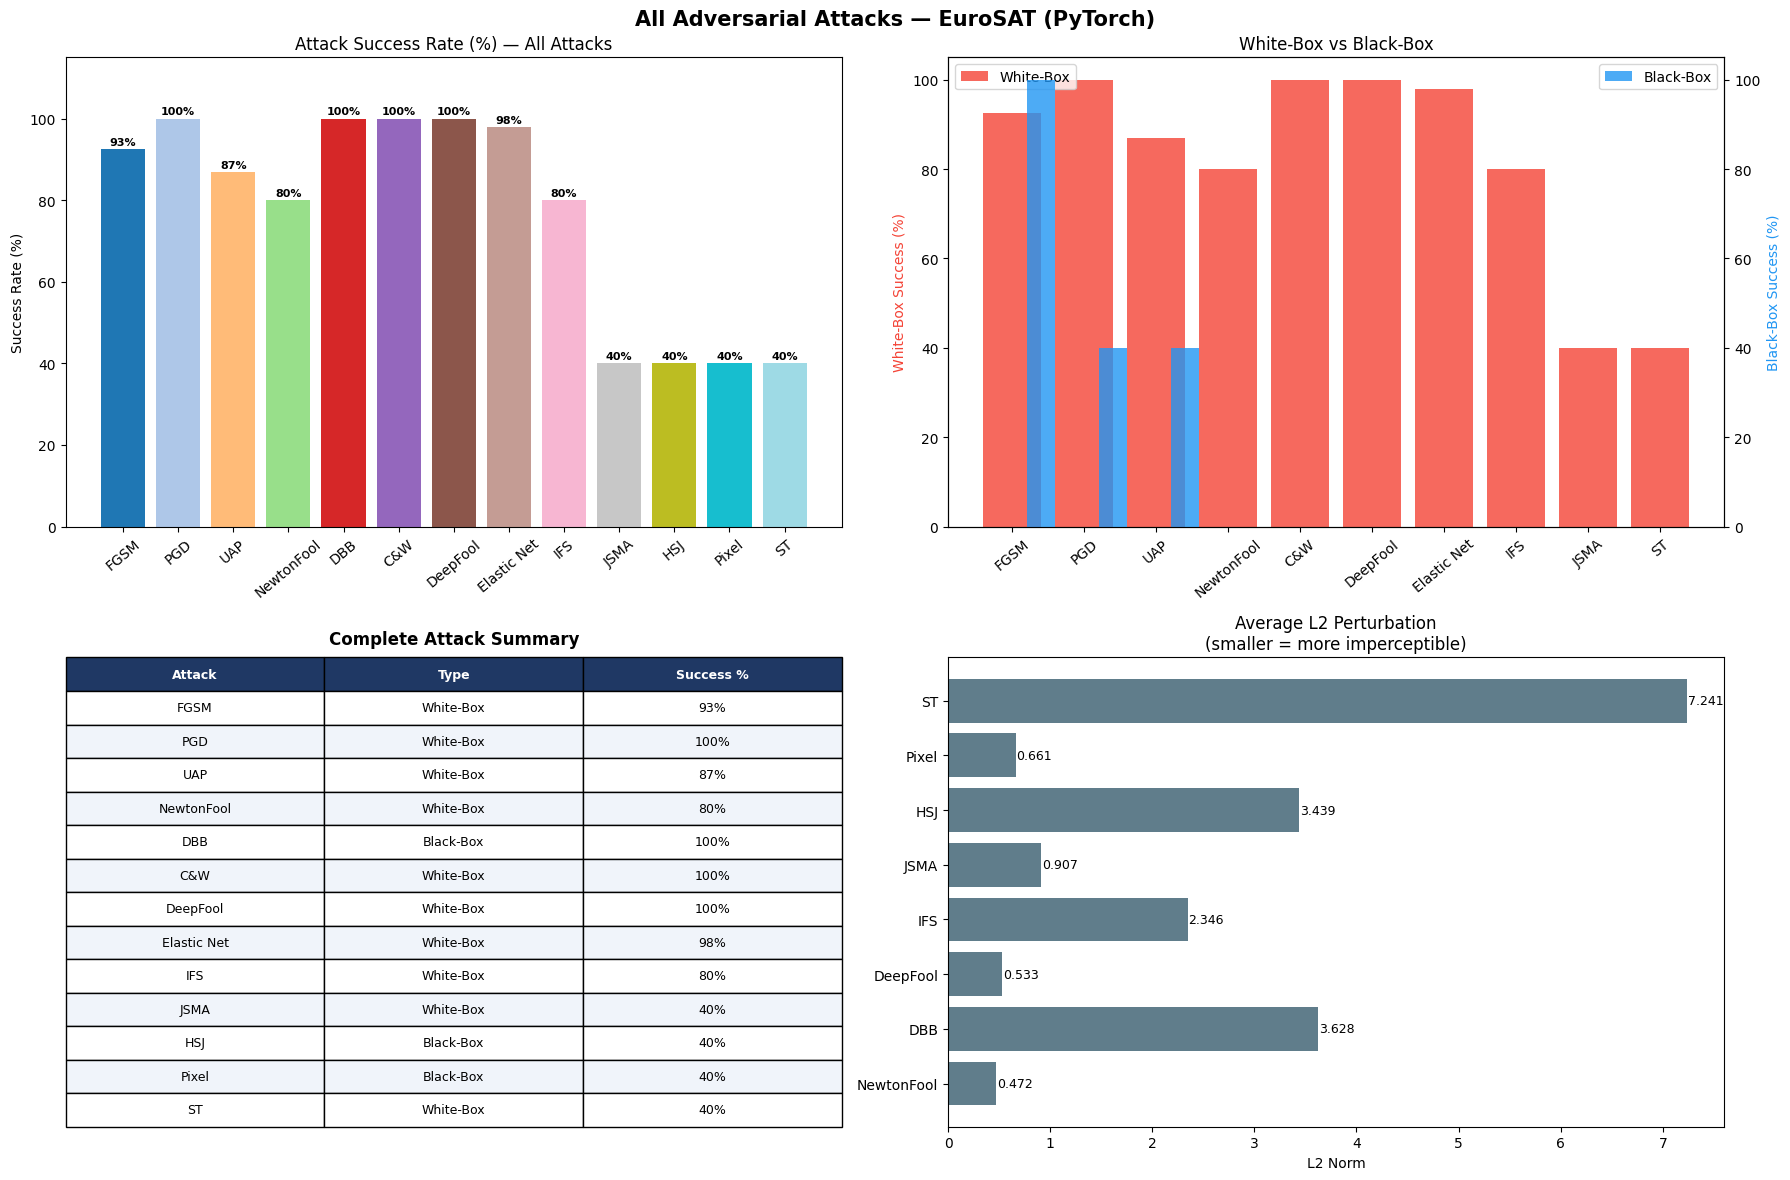

✅ Final comparison chart saved!


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("All Adversarial Attacks — EuroSAT (PyTorch)", fontsize=15, fontweight="bold")

all_attacks = ["FGSM", "PGD", "UAP", "NewtonFool", "DBB", "C&W", "DeepFool",
               "Elastic Net", "IFS", "JSMA", "HSJ", "Pixel", "ST"]
all_success = [
    100 - fgsm_accuracies[3],
    100 - pgd_accuracies[2],
    100 - uap_acc,
    nf_success / 5 * 100,
    dbb_success / 5 * 100,
    100 - cw_accuracies[2],
    df_success / 5 * 100,
    100 - en_accuracies[2],
    ifs_success / 5 * 100,
    jsma_success / 5 * 100,
    hsj_success / 5 * 100,
    pa_success / 5 * 100,
    st_success / 5 * 100,
]
colors = plt.cm.tab20(np.linspace(0, 1, len(all_attacks)))

ax = axes[0, 0]
bars = ax.bar(all_attacks, all_success, color=colors)
ax.set_title("Attack Success Rate (%) — All Attacks")
ax.set_ylabel("Success Rate (%)"); ax.set_ylim(0, 115)
ax.tick_params(axis="x", rotation=40)
for bar, val in zip(bars, all_success):
    ax.text(bar.get_x()+bar.get_width()/2, val+1, f"{val:.0f}%", ha="center", fontsize=8, fontweight="bold")

ax = axes[0, 1]
wb_attacks = ["FGSM","PGD","UAP","NewtonFool","C&W","DeepFool","Elastic Net","IFS","JSMA","ST"]
wb_success = [100-fgsm_accuracies[3], 100-pgd_accuracies[2], 100-uap_acc, nf_success/5*100,
              100-cw_accuracies[2], df_success/5*100, 100-en_accuracies[2],
              ifs_success/5*100, jsma_success/5*100, st_success/5*100]
bb_attacks = ["DBB","HSJ","Pixel"]
bb_success = [dbb_success/5*100, hsj_success/5*100, pa_success/5*100]
ax.bar(wb_attacks, wb_success, color="#F44336", alpha=0.8, label="White-Box")
ax2 = ax.twinx()
ax2.bar([x + 0.4 for x in range(len(bb_attacks))], bb_success, color="#2196F3", alpha=0.8, width=0.4, label="Black-Box")
ax.set_title("White-Box vs Black-Box"); ax.set_ylabel("White-Box Success (%)", color="#F44336")
ax2.set_ylabel("Black-Box Success (%)", color="#2196F3")
ax.tick_params(axis="x", rotation=40); ax.legend(loc="upper left"); ax2.legend(loc="upper right")

ax = axes[1, 0]; ax.axis("off")
table_data = [["Attack", "Type", "Success %"]] + [
    [name, "White-Box" if name in wb_attacks else "Black-Box", f"{s:.0f}%"]
    for name, s in zip(all_attacks, all_success)
]
table = ax.table(cellText=table_data[1:], colLabels=table_data[0], cellLoc="center", loc="center", bbox=[0,0,1,1])
table.auto_set_font_size(False); table.set_fontsize(9)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1F3864"); cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#F0F4FA")
ax.set_title("Complete Attack Summary", fontweight="bold", pad=10)

ax = axes[1, 1]
l2_attacks = ["NewtonFool","DBB","DeepFool","IFS","JSMA","HSJ","Pixel","ST"]
l2_vals = [
    np.mean([r["l2"] for r in nf_results]),
    np.mean([r["l2"] for r in dbb_results]),
    np.mean([r["l2"] for r in df_results]),
    np.mean([r["l2"] for r in ifs_results]),
    np.mean([r["l2"] for r in jsma_results]),
    np.mean([r["l2"] for r in hsj_results]),
    np.mean([r["l2"] for r in pa_results]),
    np.mean([r["l2"] for r in st_results]),
]
ax.barh(l2_attacks, l2_vals, color="#607D8B")
ax.set_title("Average L2 Perturbation\n(smaller = more imperceptible)")
ax.set_xlabel("L2 Norm")
for i, val in enumerate(l2_vals):
    ax.text(val + 0.01, i, f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("all_attacks_final_pytorch.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Final comparison chart saved!")

## 20. Flask API


In [27]:
from flask import Flask, request, jsonify
import threading, base64, io
from PIL import Image

app = Flask(__name__)

# Reload the trained model fresh, for the API process
api_model = EuroSATCNN(NUM_CLASSES).to(device)
api_model.load_state_dict(torch.load("eurosat_model.pt", map_location=device))
api_model.eval()

def decode_image(b64_string):
    img_bytes = base64.b64decode(b64_string)
    img = Image.open(io.BytesIO(img_bytes)).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img).astype(np.float32) / 255.0        # H,W,C
    tensor = torch.tensor(arr).permute(2, 0, 1).to(device)  # C,H,W
    return tensor

def encode_image(tensor):
    arr = (tensor.detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    img = Image.fromarray(arr)
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()

@app.route("/predict", methods=["POST"])
def predict():
    img = decode_image(request.json["image"])
    pred = predict_label(api_model, img)
    return jsonify({"prediction": CLASS_NAMES[pred], "class_index": pred})

@app.route("/fgsm", methods=["POST"])
def api_fgsm():
    img = decode_image(request.json["image"])
    eps = float(request.json.get("epsilon", 0.1))
    lbl = torch.tensor([predict_label(api_model, img)], device=device)
    adv = fgsm_attack(api_model, img.unsqueeze(0), lbl, eps)[0]
    return jsonify({
        "original_prediction": CLASS_NAMES[lbl.item()],
        "adversarial_prediction": CLASS_NAMES[predict_label(api_model, adv)],
        "adversarial_image": encode_image(adv)
    })

@app.route("/pgd", methods=["POST"])
def api_pgd():
    img = decode_image(request.json["image"])
    eps = float(request.json.get("epsilon", 0.1))
    lbl = torch.tensor([predict_label(api_model, img)], device=device)
    adv = pgd_attack(api_model, img.unsqueeze(0), lbl, epsilon=eps, alpha=eps/10, num_steps=40)[0]
    return jsonify({
        "original_prediction": CLASS_NAMES[lbl.item()],
        "adversarial_prediction": CLASS_NAMES[predict_label(api_model, adv)],
        "adversarial_image": encode_image(adv)
    })

@app.route("/newtonfool", methods=["POST"])
def api_newtonfool():
    img = decode_image(request.json["image"])
    eta = float(request.json.get("eta", 0.01))
    steps = int(request.json.get("steps", 100))
    adv, orig_pred = newtonfool_attack(api_model, img, num_steps=steps, eta=eta)
    return jsonify({
        "original_prediction": CLASS_NAMES[orig_pred],
        "adversarial_prediction": CLASS_NAMES[predict_label(api_model, adv)],
        "adversarial_image": encode_image(adv)
    })

@app.route("/deepfool", methods=["POST"])
def api_deepfool():
    img = decode_image(request.json["image"])
    adv, orig_pred = deepfool_attack(api_model, img, NUM_CLASSES)
    return jsonify({
        "original_prediction": CLASS_NAMES[orig_pred],
        "adversarial_prediction": CLASS_NAMES[predict_label(api_model, adv)],
        "adversarial_image": encode_image(adv)
    })

@app.route("/cw", methods=["POST"])
def api_cw():
    img = decode_image(request.json["image"])
    c_val = float(request.json.get("c", 1.0))
    lbl = torch.tensor([predict_label(api_model, img)], device=device)
    adv = cw_attack(api_model, img.unsqueeze(0), lbl, NUM_CLASSES, c=c_val)[0]
    return jsonify({
        "original_prediction": CLASS_NAMES[lbl.item()],
        "adversarial_prediction": CLASS_NAMES[predict_label(api_model, adv)],
        "adversarial_image": encode_image(adv)
    })

@app.route("/elasticnet", methods=["POST"])
def api_en():
    img = decode_image(request.json["image"])
    c_val = float(request.json.get("c", 1.0))
    lbl = torch.tensor([predict_label(api_model, img)], device=device)
    adv = elastic_net_attack(api_model, img.unsqueeze(0), lbl, NUM_CLASSES, c=c_val)[0]
    return jsonify({
        "original_prediction": CLASS_NAMES[lbl.item()],
        "adversarial_prediction": CLASS_NAMES[predict_label(api_model, adv)],
        "adversarial_image": encode_image(adv)
    })

@app.route("/ifs", methods=["POST"])
def api_ifs():
    img = decode_image(request.json["image"])
    adv, orig_pred = ifs_attack(api_model, img)
    return jsonify({
        "original_prediction": CLASS_NAMES[orig_pred],
        "adversarial_prediction": CLASS_NAMES[predict_label(api_model, adv)],
        "adversarial_image": encode_image(adv)
    })

@app.route("/jsma", methods=["POST"])
def api_jsma():
    img = decode_image(request.json["image"])
    adv, orig_pred = jsma_attack(api_model, img, NUM_CLASSES)
    return jsonify({
        "original_prediction": CLASS_NAMES[orig_pred],
        "adversarial_prediction": CLASS_NAMES[predict_label(api_model, adv)],
        "adversarial_image": encode_image(adv)
    })

@app.route("/hopskipjump", methods=["POST"])
def api_hsj():
    img = decode_image(request.json["image"])
    adv, orig_pred, adv_pred = hopskipjump_attack(api_model, img, num_iter=20, num_eval=50)
    return jsonify({
        "original_prediction": CLASS_NAMES[orig_pred],
        "adversarial_prediction": CLASS_NAMES[adv_pred],
        "adversarial_image": encode_image(adv)
    })

@app.route("/pixel", methods=["POST"])
def api_pixel():
    img = decode_image(request.json["image"])
    adv, orig_pred, adv_pred = pixel_attack(api_model, img, num_pixels=5, max_iter=50)
    return jsonify({
        "original_prediction": CLASS_NAMES[orig_pred],
        "adversarial_prediction": CLASS_NAMES[adv_pred],
        "adversarial_image": encode_image(adv)
    })

@app.route("/spatial", methods=["POST"])
def api_st():
    img = decode_image(request.json["image"])
    adv, orig_pred, adv_pred = spatial_transform_attack(api_model, img)
    return jsonify({
        "original_prediction": CLASS_NAMES[orig_pred],
        "adversarial_prediction": CLASS_NAMES[adv_pred],
        "adversarial_image": encode_image(adv)
    })

@app.route("/boundary", methods=["POST"])
def api_boundary():
    img = decode_image(request.json["image"])
    adv, orig_pred = boundary_attack(api_model, img, num_steps=100)
    return jsonify({
        "original_prediction": CLASS_NAMES[orig_pred],
        "adversarial_prediction": CLASS_NAMES[predict_label(api_model, adv)],
        "adversarial_image": encode_image(adv)
    })

print("✅ Flask app defined with endpoints: /predict /fgsm /pgd /newtonfool /deepfool "
      "/cw /elasticnet /ifs /jsma /hopskipjump /pixel /spatial /boundary")

✅ Flask app defined with endpoints: /predict /fgsm /pgd /newtonfool /deepfool /cw /elasticnet /ifs /jsma /hopskipjump /pixel /spatial /boundary


In [29]:
from pyngrok import ngrok

NGROK_TOKEN = "3FTd8Xle8HYi1Yh4Zr9ja3pJorY_3mk8Li5F5qptp5mCKQSHU"
ngrok.set_auth_token(NGROK_TOKEN)

def run_flask():
    app.run(port=5000, use_reloader=False, debug=False)

thread = threading.Thread(target=run_flask)
thread.daemon = True
thread.start()

public_url = ngrok.connect(5000)
print("=" * 55)
print("✅ Adversarial Attack API is LIVE!")
print(f"   Base URL : {public_url}")
for ep in ["predict","fgsm","pgd","newtonfool","deepfool","cw","elasticnet",
           "ifs","jsma","hopskipjump","pixel","spatial","boundary"]:
    print(f"   /{ep:<12s} : {public_url}/{ep}")

 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


✅ Adversarial Attack API is LIVE!
   Base URL : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"
   /predict      : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/predict
   /fgsm         : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/fgsm
   /pgd          : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/pgd
   /newtonfool   : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/newtonfool
   /deepfool     : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/deepfool
   /cw           : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/cw
   /elasticnet   : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/elasticnet
   /ifs          : NgrokTunnel: 

In [30]:
import requests, json

sample_img = bb_images[0]
img_b64 = encode_image(sample_img)

print("TEST: /predict")
print("-" * 45)
res = requests.post("http://localhost:5000/predict", json={"image": img_b64})
print(json.dumps(res.json(), indent=2))

print("\nTEST: /fgsm")
print("-" * 45)
res = requests.post("http://localhost:5000/fgsm", json={"image": img_b64, "epsilon": 0.1})
print(json.dumps({k: v for k, v in res.json().items() if k != "adversarial_image"}, indent=2))

INFO:werkzeug:127.0.0.1 - - [13/Jul/2026 03:33:46] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jul/2026 03:33:46] "POST /fgsm HTTP/1.1" 200 -


TEST: /predict
---------------------------------------------
{
  "class_index": 1,
  "prediction": "Forest"
}

TEST: /fgsm
---------------------------------------------
{
  "adversarial_prediction": "Residential",
  "original_prediction": "Forest"
}
